In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py as h5
import sys
from tqdm import tqdm 
sys.path.append('/home/cosweeney/code/Fits/')

from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck13')
a = 0.83760
redshift=1/a-1
H = cosmo.Hz(redshift)
h = cosmo.h
print(cosmo.h, cosmo.Hz(redshift), cosmo.H0*cosmo.Ez(redshift))

sys.path.append('/home/cosweeney/code/Fits/')

sys.path.append('/home/cosweeney/code/Fits/Jocond')

from JoCond.jocond.losvd import *
from JoCond.jocond.cat import *
from JoCond.jocond.hgcf import *
from JoCond.jocond.myconfig import*

import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})

from scipy.stats import gennorm, norm, t
import warnings
warnings.filterwarnings('ignore')

from scipy.optimize import curve_fit

import pandas as pd
import os


0.6777 74.71913613009617 74.71913613009617


In [2]:
Rvirs, Mvirs, mbins = compute_bin_virial_R_M('/spiff/cosweeney/Tables/halo_pair_cat_final2_HD.hdf5')

# radial bins, just out to 30/69 for now
R_edges = np.linspace(5, 30, (30-5)+1)
R_cens = (R_edges[1:]+R_edges[:-1])/2.0 

rlos_edges = np.linspace(0, 60, (60-0)+1)
rlos_cens = (rlos_edges[1:]+rlos_edges[:-1])/2.0 

rlos_edges_dual = np.linspace(-60, 60, (60-(-60))+1)
rlos_cens_dual = (rlos_edges_dual[1:]+rlos_edges_dual[:-1])/2.0 

massbin edges, in h^-1 sol mass: [8.00020227e+13 1.22732852e+14 1.88287152e+14 2.88855436e+14
 4.43139440e+14 6.79829904e+14 1.60000000e+15]


In [5]:
# bin data, for particles this time

def bin_pairwise_particle_cat(raw_file_path, save_dir, Mvirs, R_bins, rlos_bins):
    """
    Reads HDF5 particle catalog data, bins it by R and rlos, and saves the result.
    
    Parameters:
    - raw_file_path: str, path to the raw hdf5 file
    - save_dir: str, directory where the binned data should be saved
    - Mvirs: list/array, the mass bins (used to iterate over the input HDF5 groups)
    - R_bins: array-like, the bin edges for R
    - rlos_bins: array-like, the bin edges for rlos
    
    Returns:
    - binned_dict: A nested dictionary structured as dict[k][R_bin_idx][rlos_bin_idx]['vpeclos']
    - master_df: The full Pandas DataFrame for advanced querying.
    """
    all_dfs = []
    
    # 1. Read and compile all data into a single DataFrame
    with h5.File(raw_file_path, 'r') as hdf:
        for k in range(len(Mvirs)):
            # Load data for mass bin 'k'
            df = pd.DataFrame({
                'R': hdf[f'R/{k}'][()],
                'rlos': hdf[f'rlos/{k}'][()],
                'vpeclos': hdf[f'vpeclos/{k}'][()],
                'vphyslos': hdf[f'vphyslos/{k}'][()],
                #'Mvir': hdf[f'Mvir/{k}'][()],
                'k_idx': k  # Track the mass index
            })
            
            # 2. Apply binning using pd.cut
            # labels=False returns integer indices for the bins
            df['R_bin'] = pd.cut(df['R'], bins=R_bins, labels=False, include_lowest=True)
            df['rlos_bin'] = pd.cut(df['rlos'], bins=rlos_bins, labels=False, include_lowest=True)
            
            # Drop data points that fall completely outside your defined bin edges
            df = df.dropna(subset=['R_bin', 'rlos_bin']).copy()
            
            # Convert bin labels to integers
            df['R_bin'] = df['R_bin'].astype(int)
            df['rlos_bin'] = df['rlos_bin'].astype(int)
            
            all_dfs.append(df)
            
    # Combine everything
    master_df = pd.concat(all_dfs, ignore_index=True)
    
    # 3. Generate an indicative filename based on the bin inputs
    # Format: binned_M[len]_R[len]_[min]-[max]_rlos[len]_[min]-[max].h5
    filename = (
        f"particle_binned_M{len(Mvirs)}_"
        f"R{len(R_bins)-1}_{R_bins[0]:.1f}-{R_bins[-1]:.1f}_"
        f"rlos{len(rlos_bins)-1}_{rlos_bins[0]:.1f}-{rlos_bins[-1]:.1f}.h5"
    )
    save_path = os.path.join(save_dir, filename)
    
    # 4. Save the DataFrame to disk for easy retrieval later
    # Format 'table' allows for fast querying directly from the hard drive later if needed
    master_df.to_hdf(save_path, key='binned_data', mode='w', format='table')
    print(f"Successfully saved binned data to: {save_path}")
    
    # 5. Build a nested dictionary for immediate in-script analysis
    binned_dict = {}
    
    # Pandas groupby handles the 3D separation (M, R, rlos) in one fast sweep
    for (k, r_i, rlos_i), group in master_df.groupby(['k_idx', 'R_bin', 'rlos_bin']):
        if k not in binned_dict:
            binned_dict[k] = {}
        if r_i not in binned_dict[k]:
            binned_dict[k][r_i] = {}
            
        binned_dict[k][r_i][rlos_i] = {
            'vpeclos': group['vpeclos'].values,
            'vphyslos': group['vphyslos'].values,
            'rlos': group['rlos'].values,
            'R': group['R'].values,
            #'Mvir': group['Mvir'].values
        }
        
    return binned_dict, master_df

In [6]:
# bin sim data in bins of R, r_los (for negative rlos as well this time)
vel_path = '/spiff/cosweeney/simulations/MDPL2/data/pairwise_velocity_selections/particle_rel_v_R_mass_cyl.hdf5'

data_dict, df = bin_pairwise_particle_cat(
    raw_file_path=vel_path, 
    save_dir='/spiff/cosweeney/simulations/MDPL2/data/binned_data', 
    Mvirs=Mvirs, 
    R_bins=R_edges, 
    rlos_bins=rlos_edges_dual
)

Successfully saved binned data to: /spiff/cosweeney/simulations/MDPL2/data/binned_data/particle_binned_M6_R25_5.0-30.0_rlos120_-60.0-60.0.h5


In [7]:
def skewed_t_pdf(x, xi, omega, alpha, nu):
    """
    Azzalini & Capitanio skewed t-distribution PDF
    
    Parameters:
    xi: location parameter
    omega: scale parameter (> 0)
    alpha: skewness parameter
    nu: degrees of freedom (> 0)
    """
    # Standardize
    z = (x - xi) / omega
    
    # Student's t PDF
    t_pdf = t.pdf(z, df=nu)
    
    # Student's t CDF with modified argument
    t_cdf = t.cdf(alpha * z * np.sqrt((nu + 1) / (nu + z**2)), df=nu + 1)
    
    # Skewed t PDF
    pdf = (2 / omega) * t_pdf * t_cdf
    
    return pdf


In [14]:
# fit skew-t to P(v_pec|R, rlos) with fixed nu for grid of nu

nu = 6
STpars = np.zeros((len(Mvirs), len(R_cens), len(rlos_cens_dual), 3))
STerrs = np.zeros(STpars.shape)

for k in range(len(Mvirs)):
    for j in range(len(R_cens)):
        for i in range(len(rlos_cens_dual)):
            try:
                index = i + j*len(rlos_cens_dual) + (k)*len(R_cens)*len(rlos_cens_dual)

                r = np.sqrt(R_cens[j]**2 + rlos_cens_dual[i]**2)
                theta = np.arctan2(rlos_cens_dual[i], R_cens[j])
                sin = np.sin(theta)

                peak = 0#interps[k](r)*sin #+ a*H*rlos_cens_dual[i]/h

                ve = np.linspace(peak-2500, peak+2500, 50+1)
                vc = 0.5*(ve[1:] + ve[:-1])

                hist, edges = np.histogram(data_dict[k][j][i]['vpeclos'], bins=ve, density=True)
                cent = 0.5*(edges[1:] + edges[:-1])

                if np.isnan(hist).any():
                    break
                else:

                    p, c = curve_fit(lambda x, xi, omega, alpha: skewed_t_pdf(x, xi, omega, alpha, nu=nu), cent, hist, p0=[peak, 400, np.sign(rlos_cens_dual[j])*(-0.1)], maxfev=5_000)
                    
                    STpars[k, j, i] = p
                    STerrs[k, j, i] = np.sqrt(np.diag(c))
            
            except RuntimeError as e:
                # Fit failed to converge - skip this bin
                print(f"Fit failed for bin (k={k}, j={j}, i={i}): {e}")
                continue
            except Exception as e:
                # Catch any other errors
                print(f"Unexpected error for bin (k={k}, j={j}, i={i}): {e}")
                continue

Fit failed for bin (k=4, j=2, i=1): Optimal parameters not found: Number of calls to function has reached maxfev = 5000.
Fit failed for bin (k=4, j=4, i=0): Optimal parameters not found: Number of calls to function has reached maxfev = 5000.
Fit failed for bin (k=4, j=7, i=1): Optimal parameters not found: Number of calls to function has reached maxfev = 5000.
Fit failed for bin (k=4, j=7, i=3): Optimal parameters not found: Number of calls to function has reached maxfev = 5000.
Fit failed for bin (k=5, j=0, i=118): Optimal parameters not found: Number of calls to function has reached maxfev = 5000.
Fit failed for bin (k=5, j=1, i=2): Optimal parameters not found: Number of calls to function has reached maxfev = 5000.
Fit failed for bin (k=5, j=1, i=3): Optimal parameters not found: Number of calls to function has reached maxfev = 5000.
Fit failed for bin (k=5, j=1, i=117): Optimal parameters not found: Number of calls to function has reached maxfev = 5000.
Fit failed for bin (k=5, j=2

In [11]:
save_path = '/spiff/cosweeney/simulations/MDPL2/data/models'

data = np.load(save_path+'vr_peak_r_RBS_data.npz')
from scipy.interpolate import RectBivariateSpline

# Re-initialize the object (we use a dummy grid then overwrite)
RBinterp = RectBivariateSpline.__new__(RectBivariateSpline) #RectBivariateSpline([], [], np.empty((0,0))) 
RBinterp.tck = (data['tx'], data['ty'], data['c'])
RBinterp.degrees = (data['kx'], data['ky'])

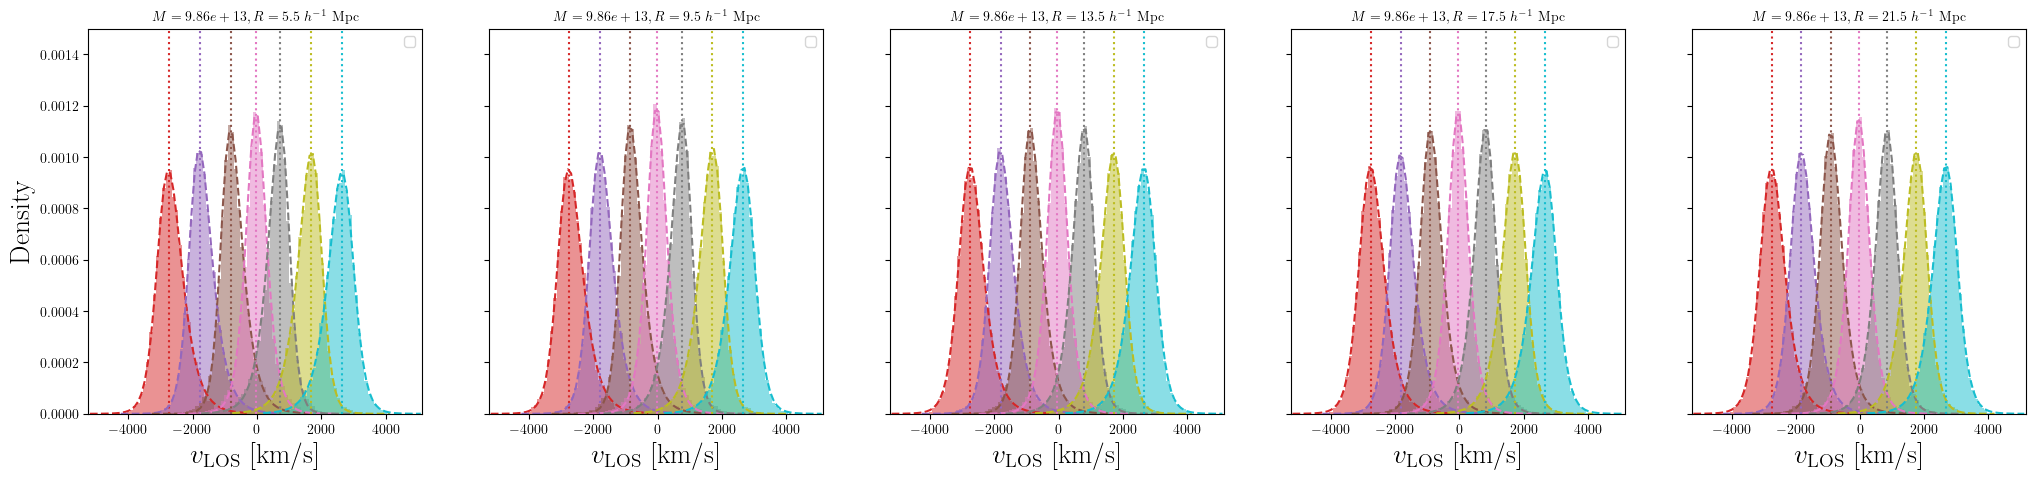

In [18]:
# validate Fits 


R_inds    = [0, 4, 8, 12, 16]
rlos_inds = [29, 39, 49, 59, 69, 79, 89]#[0, 9, 19, 29, 39, 49, 59]

for k in range(len(Mvirs)-5):
    
    fig, ax = plt.subplots(1, len(R_inds), figsize=(5*len(R_inds), 5), sharey=True)

    for j in R_inds:
        for i in rlos_inds:
            index = i + j*len(rlos_cens_dual) + (k//5)*len(R_cens)*len(rlos_cens_dual)

            r = np.sqrt(R_cens[j]**2 + rlos_cens_dual[i]**2)
            theta = np.arctan2(rlos_cens_dual[i], R_cens[j])
            sin = np.sin(theta)

            mu = RBinterp(np.log10(Mvirs[k]), r).squeeze()*sin
            peak = mu + a*H*rlos_cens_dual[i]/h

            ve = np.linspace(peak-2500, peak+2500, 50+1)
            vc = 0.5*(ve[1:] + ve[:-1])

            # hist, edges = np.histogram(data_dict[k][j][i]['vphyslos'], bins=ve, density=True)
            # cent = 0.5*(edges[1:] + edges[:-1])

            test_hist, bins, _ = ax[j//4].hist(data_dict[k][j][i]['vphyslos'], bins=ve, density=True, alpha=0.5, color=f'C{i//9}')
            cens = 0.5*(bins[1:] + bins[:-1])

            ax[j//4].plot(cens, skewed_t_pdf(cens-a*H*rlos_cens_dual[i]/h, STpars[k, j, i, 0], STpars[k, j, i, 1], STpars[k, j, i, 2], nu), c=f'C{i//9}', ls ='--',)


            ax[j//4].axvline(peak, color=f'C{i//9}', ls=':')

            ax[j//4].set_title(rf"$M={Mvirs[k]:.2e}, R = {R_cens[j]}$ $h^{{-1}}$ Mpc ", fontsize=10)
            ax[j//4].set_xlabel(r"$v_{\rm LOS}$ [km/s]", fontsize=20)
            ax[0].set_ylabel(r"Density", fontsize=20)
            ax[j//4].margins(x=0) 

            #if i == rlos_inds[0]:
            ax[j//4].legend()
            ax[j//4].set_ylim((0, 0.0015))

In [19]:
STpars.shape

(6, 25, 120, 3)

In [20]:
STpars_in = STpars[:, :, 29:89]
STerrs_in = STerrs[:, :, 29:89]

In [29]:
STpars_in.shape

(6, 25, 60, 3)

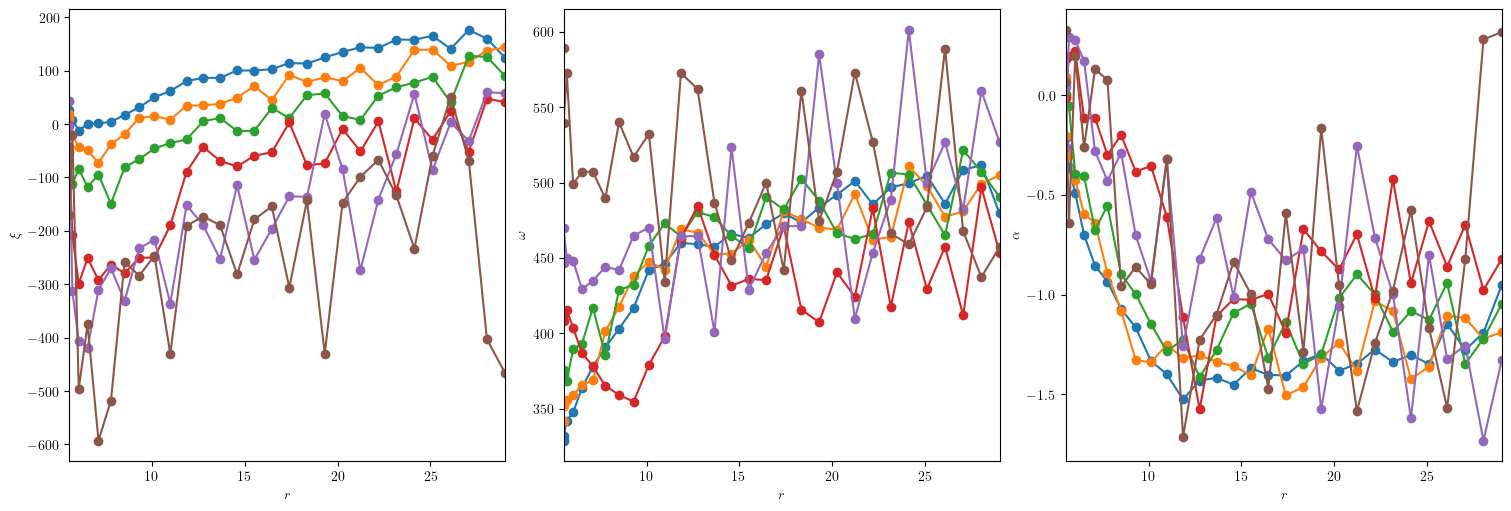

In [48]:
# plot parameters as a function of r3d

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

colormap_list = [plt.cm.Blues, plt.cm.Oranges, plt.cm.Greens, 
                 plt.cm.Reds, plt.cm.Purples, plt.cm.Greys]

cmaps = [cmap(np.linspace(0, 1, len(R_cens))) for cmap in colormap_list]

fig, ax = plt.subplots(1, 3, layout='constrained', sharex=True, figsize=(15, 5))    

names = [r'$\xi$', r'$\omega$', r'$\alpha$']

rs_grid = np.sqrt(R_cens[:, None]**2 + rlos_cens_dual[29+30:89][None, :]**2)

for k in range(len(Mvirs)):
    for j in range(3):
        # if j ==0:
        #     y = STpars_in[k, 0, 30:, j] + a*H*rlos_cens_dual[29+30:89]/h
        # else:
        y = STpars_in[k, 0, 30:, j]

        ax[j].plot(rs_grid[0, :], y, marker='o', c=f"C{k}")
        ax[j].set_xlabel(r"$r$")
        ax[j].set_ylabel(names[j])
        ax[j].margins(x=0)

    # Norm = Normalize(vmin=min(R_cens), vmax=max(R_cens))
    # sm = ScalarMappable(norm=Norm, cmap=colormap_list[k])
    # sm.set_array([])  # dummy array
    # cbar = fig.colorbar(sm, ax=ax[j])
    # cbar.set_label(r"$R \ [h^{-1}$ Mpc]", fontsize=20)
    # ax[j].set_facecolor('lightgray')
